# 03 — Salsa Dance Motion Autoencoder

We train a **vanilla GRU autoencoder** on Salsa dance motion sequences, using the same architecture as the Salsa motion representation project. Flow: load data → train AE → latent space → reconstruction.

**Data:** Salsa dance pairs from LMDB (InterHuman representation, 262 dims, 19-frame windows).

**Note:** Run with `conda activate motionagent` (or the env with `lmdb`, `pyarrow` for Salsa data).

## Imports and setup

In [1]:
import warnings
warnings.filterwarnings("ignore", message=".*pyarrow.deserialize.*deprecated.*")

import torch
import numpy as np
from pathlib import Path
from salsa_utils import (
    get_salsa_model,
    get_salsa_loaders,
    SalsaAETrainer,
    scatter_latent_salsa,
    plot_motion_frame,
    animate_skeleton_3d_gif,
)

SALSA_ROOT = Path("/local-scratch/localhome/pjomeyaz/Payam_Files/Projects/Salsa_Dance/scripts/New_2025/Salsa-Agent")

## Load data

Uses Salsa motion_representation's `create_dataloader` (no changes to their code). InterHuman: (19, 262) windows.

In [2]:
seq_len, input_dim = 19, 262  # InterHuman: window_size-1 frames, 262 dims
train_loader, val_loader = get_salsa_loaders(
    salsa_root=SALSA_ROOT,
    representation_type="interhuman",
    window_size=20,
    stride=10,
    batch_size=32,
    num_workers=0,
    use_both_roles=True,
    normalize=True,
)
print("Train batches:", len(train_loader), ", Val batches:", len(val_loader))
# Inspect one batch
batch = next(iter(train_loader))
print("Batch shape:", batch.shape)  # (B, 19, 262)

Loading cached windows from /local-scratch/localhome/pjomeyaz/Payam_Files/Projects/Salsa_Dance/scripts/New_2025/Salsa-Agent/dataset_processed_New/lmdb_Salsa_pair/lmdb_train_interhuman_20frames_cache...
Loaded 34581 motion windows from cache.
Using both leader and follower: 69162 total training samples.
Loading normalization statistics from /local-scratch/localhome/pjomeyaz/Payam_Files/Projects/Salsa_Dance/scripts/New_2025/Salsa-Agent/dataset_processed_New/lmdb_Salsa_pair/lmdb_train_interhuman_20frames_cache/normalization_stats_interhuman.pkl...
Loading cached windows from /local-scratch/localhome/pjomeyaz/Payam_Files/Projects/Salsa_Dance/scripts/New_2025/Salsa-Agent/dataset_processed_New/lmdb_Salsa_pair/lmdb_val_interhuman_20frames_cache...
Loaded 900 motion windows from cache.
Using both leader and follower: 1800 total training samples.
Loading normalization statistics from /local-scratch/localhome/pjomeyaz/Payam_Files/Projects/Salsa_Dance/scripts/New_2025/Salsa-Agent/dataset_processe

## Visualize: 3D skeleton animation

Animate a sample as a dancing skeleton (saved as GIF). Uses plot_3d_motion from Salsa motion representation.

100%|██████████| 20/20 [00:01<00:00, 15.42it/s]

Saved: salsa_sample.gif


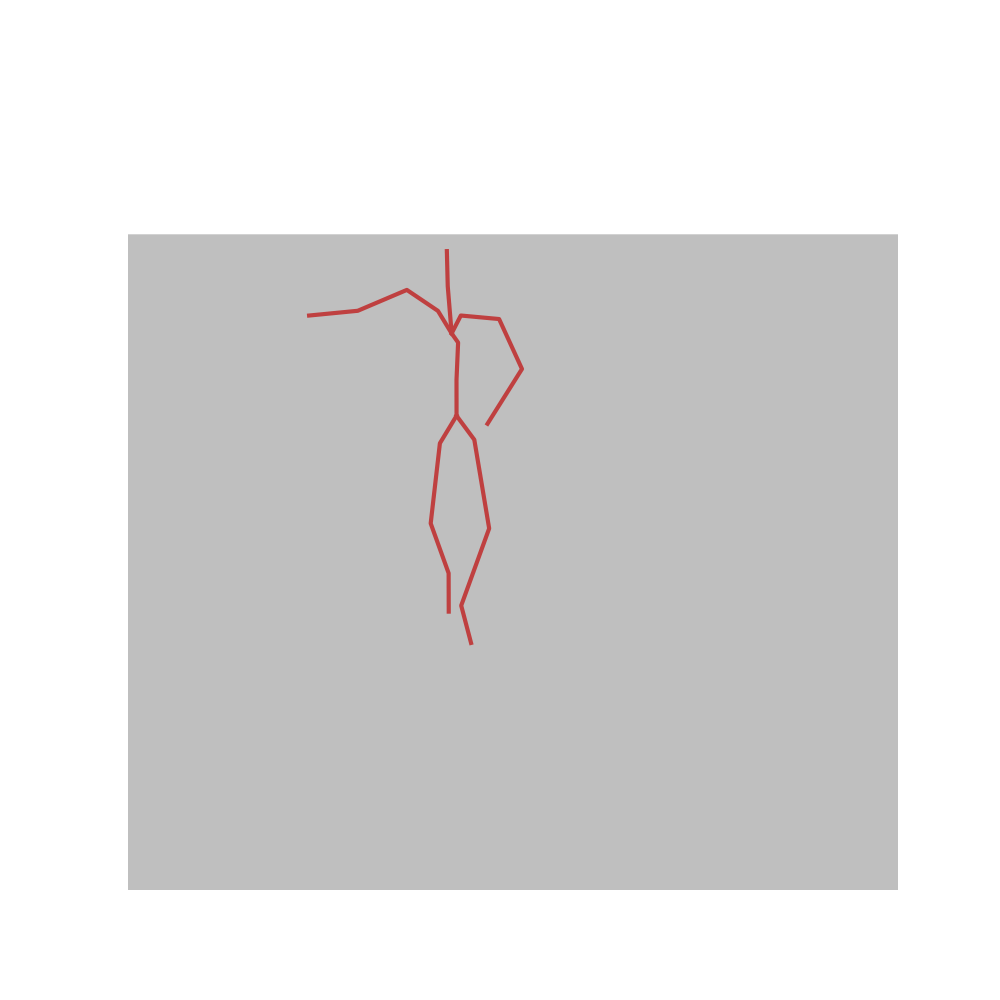

In [3]:
# Pick a sample and animate as 3D skeleton
sample = next(iter(train_loader))
motion = sample[0].numpy()  # (19, 262)
ds = train_loader.dataset
mean = ds.mean.numpy() if ds.mean is not None else None
std = ds.std.numpy() if ds.std is not None else None
animate_skeleton_3d_gif(
    motion,
    save_path="salsa_sample.gif",
    representation_type="interhuman",
    mean=mean,
    std=std,
    title="Salsa dance sample",
    fps=15,
)

## Model and training

Vanilla GRU AE matching Salsa architecture: bidirectional encoder, autoregressive decoder, dropout.

  0%|          | 0/2162 [00:00<?, ?it/s]

====> Epoch: 1 Train loss: 0.4593
====> Epoch: 1 Val loss: 0.3548


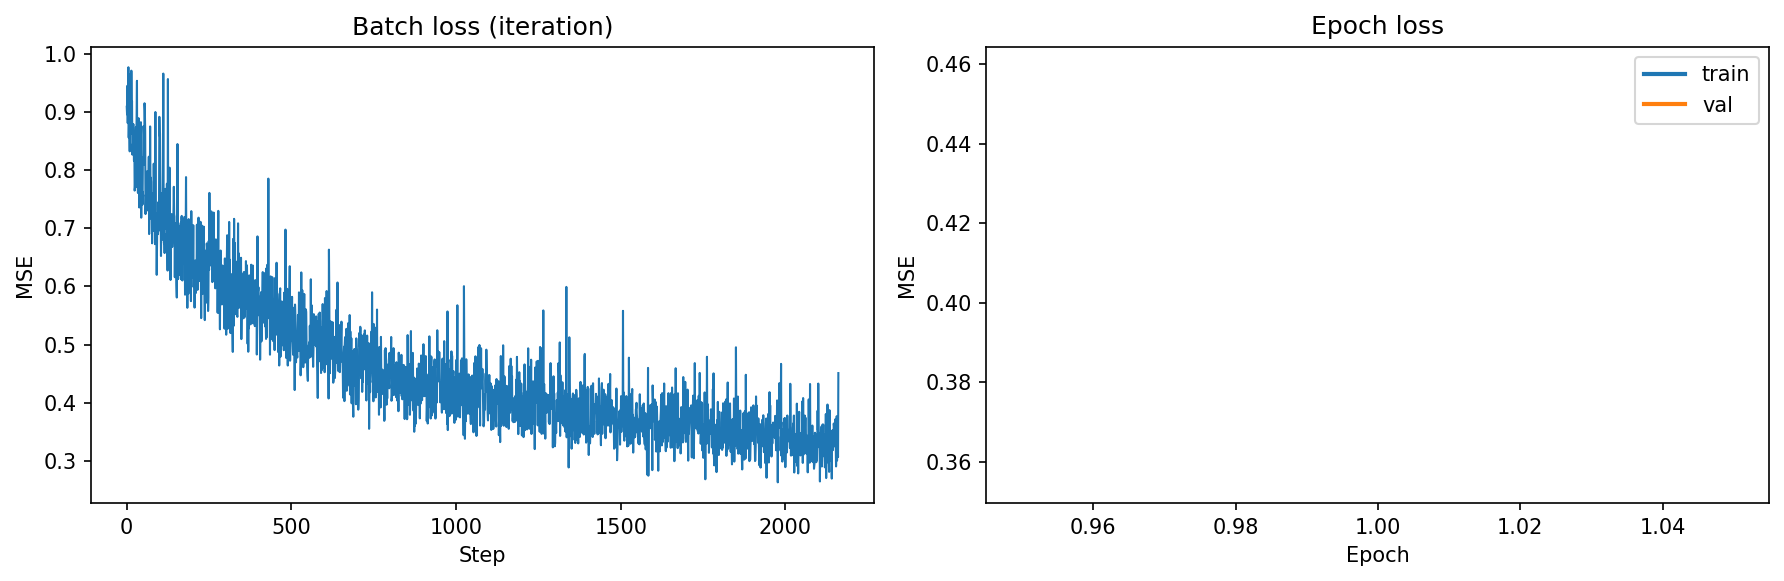

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_salsa_model(
    input_dim=input_dim,
    hidden_dim=512,
    num_layers=2,
    latent_dim=512,
    seq_len=seq_len,
    dropout=0.1,
)
trainer = SalsaAETrainer(model, train_loader, val_loader, learning_rate=2e-4, device=device)
trainer.run(n_epochs=1)

## Latent space

Encode validation set and visualize with t-SNE.

Latents shape: (1800, 512)


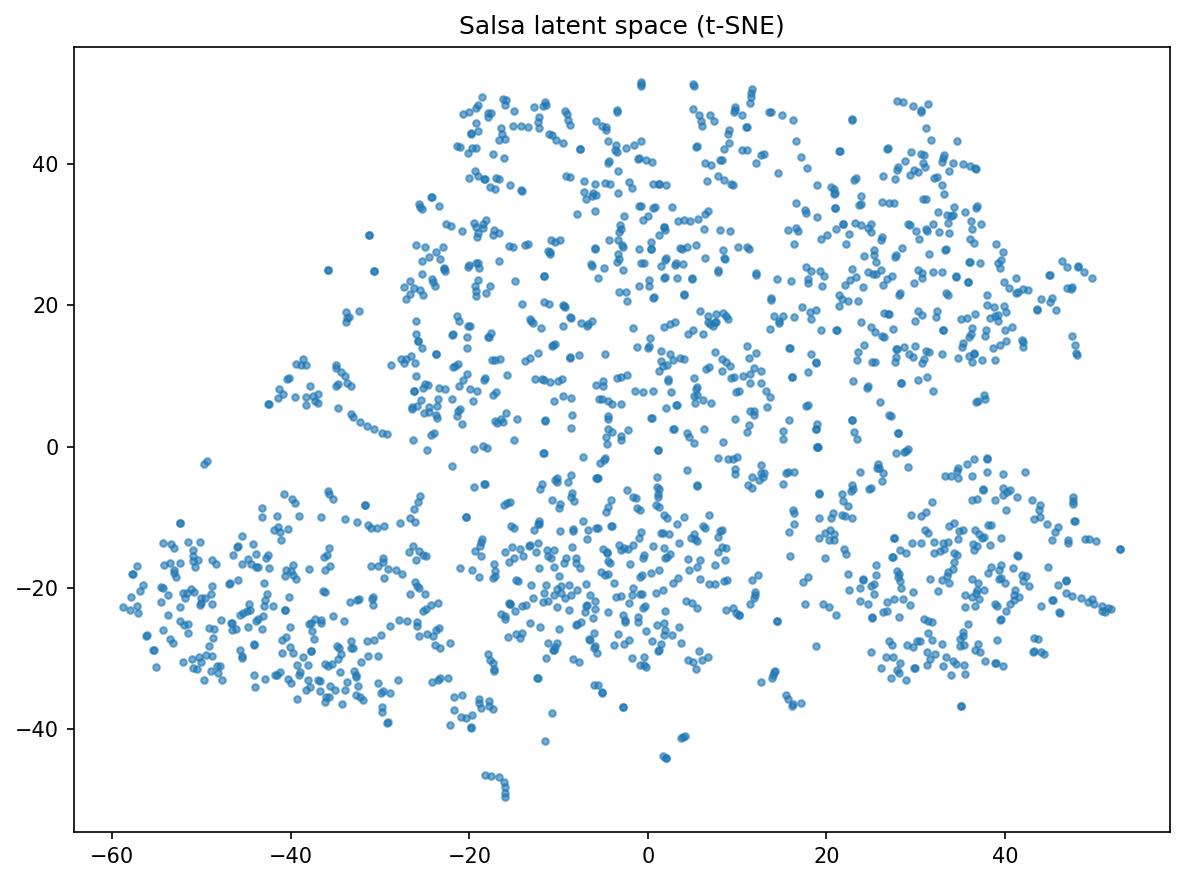

In [6]:
model.eval()
latents = []
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        z, mean, logvar = model.inference_encode(batch)
        latents.append(z.cpu().numpy())
latents = np.concatenate(latents, axis=0)
print("Latents shape:", latents.shape)
scatter_latent_salsa(latents, use_tsne=True, title="Salsa latent space (t-SNE)")

## Reconstruction

Compare original vs reconstructed motion. Animate both as 3D skeletons (GIF).

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:01<00:00, 16.11it/s]

Saved: salsa_original.gif


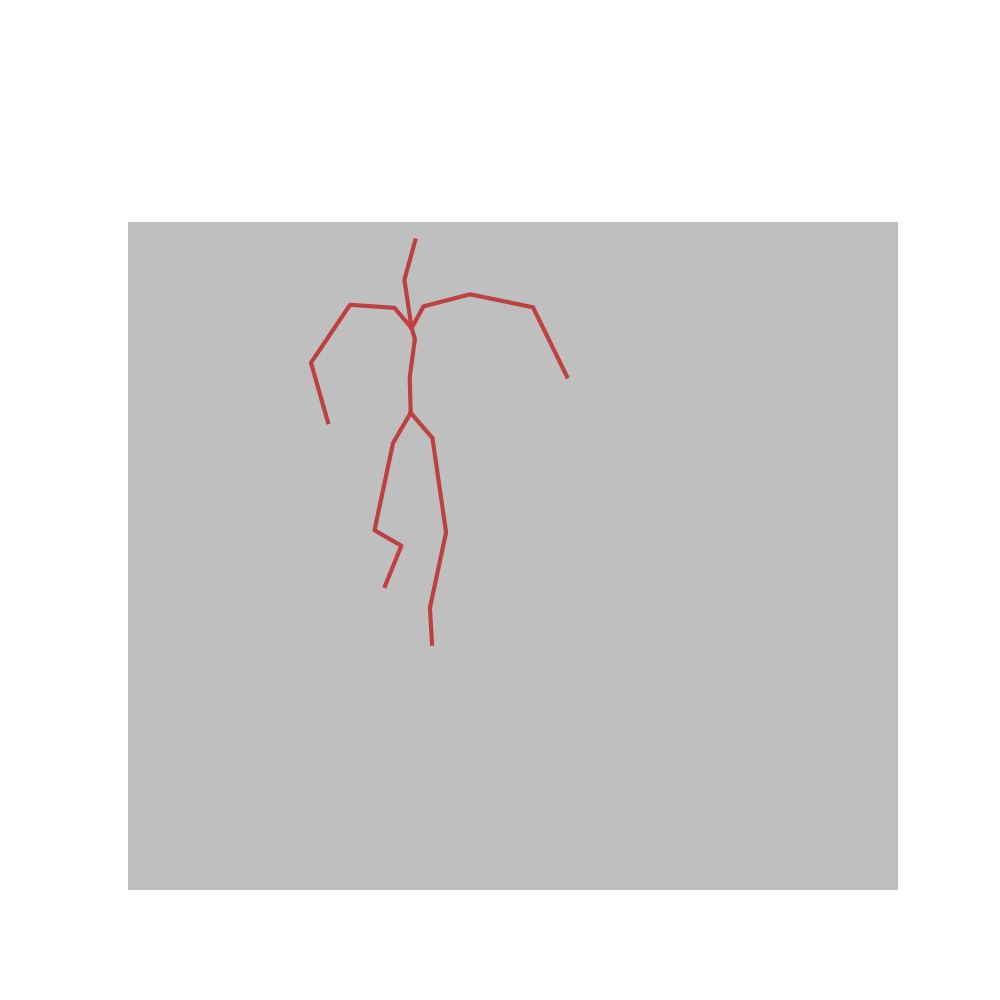

100%|██████████| 20/20 [00:01<00:00, 16.76it/s]

Saved: salsa_reconstructed.gif


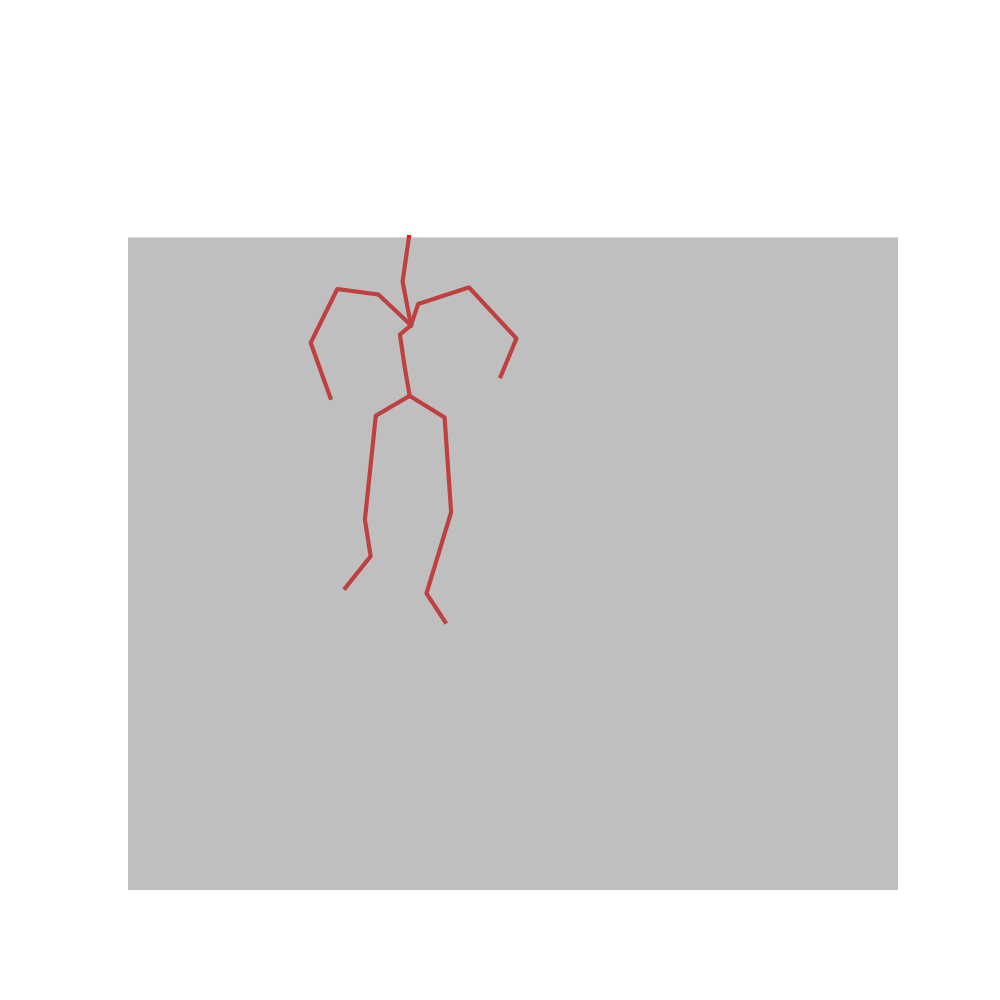

In [7]:
idx = 0
model.eval()
with torch.no_grad():
    sample = val_loader.dataset[idx]  # (19, 262) tensor
    data = sample.unsqueeze(0).to(device)
    recon, _, _, z = model(data)
orig = data[0].cpu().numpy()
recon_np = recon[0].cpu().numpy()
ds = val_loader.dataset
norm_mean = ds.mean.numpy() if ds.mean is not None else None
norm_std = ds.std.numpy() if ds.std is not None else None
# 3D skeleton animations (GIF)
animate_skeleton_3d_gif(orig, "salsa_original.gif", "interhuman", norm_mean, norm_std, "Original", fps=15)
animate_skeleton_3d_gif(recon_np, "salsa_reconstructed.gif", "interhuman", norm_mean, norm_std, "Reconstructed", fps=15)